# MRMS Precipitation Plots
By: Ty Janoski

## Setup

In [1]:
# import statements

import gzip
import tempfile
from io import BytesIO

import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots  # noqa: F401
import xarray as xr
from botocore import UNSIGNED
from botocore.config import Config
from matplotlib.colors import PowerNorm
from metpy.plots import ctables
from scipy.interpolate import griddata

plt.style.use(["science", "nature"])
plt.rcParams["text.usetex"] = True
%config InlineBackend.figure_format="retina"


In [2]:
# Make the above code into a function
def read_in_mrms_data(bucket_name: str, path: str, hour: str) -> xr.DataArray:
    # Set up S3 client
    s3 = boto3.client(
        "s3", region_name="us-east-1", config=Config(signature_version=UNSIGNED)
    )

    # List objects from AWS Bucket
    response = s3.list_objects_v2(Bucket=bucket_name, Prefix=path)

    # Find key containing hour.grib2.gz, which is the file we want
    for obj in response["Contents"]:
        if f"{hour}.grib2.gz" in obj["Key"]:
            key = obj["Key"]
            break

    # Read in the file
    grib_data = BytesIO()
    s3.download_fileobj(bucket_name, key, grib_data)
    grib_data.seek(0)

    with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tmp_file:
        with gzip.open(grib_data, "rb") as f:
            tmp_file.write(f.read())
        tmp_file_path = tmp_file.name

        da = xr.open_dataarray(tmp_file_path, engine="cfgrib")

    return da


In [3]:
# Read in 0100-0200 UTC hourly rainfall and the
# 24-hour accumulated rainfall for 1200-1200 UTC 1-2 September 2021

# Set bucket name
bucket_name = "noaa-mrms-pds"

# Read in rainfall
hourly = read_in_mrms_data(
    bucket_name, "CONUS/MultiSensor_QPE_01H_Pass2_00.00/20210902/", "020000"
)
daily = read_in_mrms_data(
    bucket_name, "CONUS/MultiSensor_QPE_24H_Pass2_00.00/20210902/", "120000"
)

dates = ["1", "2", "2"]
refl_times = ["230039", "000039", "010038"]
# Read in composite reflectivity
refl = xr.concat(
    [
        read_in_mrms_data(
            bucket_name,
            "CONUS/MergedReflectivityQCComposite_00.50/2021090" + d + "/",
            t,
        )
        for d, t in zip(dates, refl_times)
    ],
    dim="time",
)

shear_times = ["230018", "000015", "010021"]
# Read in 0-2 km azimuthal shear
shear = xr.concat(
    [
        read_in_mrms_data(
            bucket_name,
            "CONUS/MergedAzShear_0-2kmAGL_00.50/2021090" + d + "/",
            t,
        )
        for d, t in zip(dates, shear_times)
    ],
    dim="time",
)


/home/janoski/miniforge3/envs/wof/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/janoski/miniforge3/envs/wof/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will re

In [4]:
# Read in any WoFS simulation to get some projection attrs
wofs = xr.open_dataset("/mnt/drive2/new-wofs/20Z/wofs_ALL_43_20210901_2000_2335.nc")
wofs_lat = wofs.xlat
wofs_lon = wofs.xlon

# Set up Cartopy projection
proj = ccrs.LambertConformal(
    central_longitude=wofs.attrs["CEN_LON"],
    central_latitude=wofs.attrs["CEN_LAT"],
    standard_parallels=(30, 60),
)

# latitude and longitude
lat = hourly.latitude
lon = hourly.longitude

refl_lat = refl.latitude
refl_lon = refl.longitude

shear_lat = shear.latitude
shear_lon = shear.longitude

# Get MetPy ctable for precip
precip_cmap = ctables.registry.get_colortable("precipitation")
refl_cmap = ctables.registry.get_colortable("NWSReflectivity")


In [5]:
# Load the HURDAT2 file
file_path = "data/hurdat2.csv"  # Update with actual path
with open(file_path, "r") as f:
    lines = f.readlines()

# Find the start of Hurricane Ida (2021) using its unique storm ID
ida_start = None
for i, line in enumerate(lines):
    if line.startswith("AL092021,") and "IDA" in line:  # Match the storm ID and name
        ida_start = i
        break

# Extract Hurricane Ida's data block
ida_lines = []
for i in range(ida_start + 1, len(lines)):
    if lines[i][0].isalpha():  # Stop at the next storm entry
        break
    ida_lines.append(lines[i].strip())

# Convert to DataFrame
columns = [
    "Date",
    "Time",
    "Record ID",
    "Status",
    "Latitude",
    "Longitude",
    "Max Wind (kt)",
    "Min Pressure (mb)",
]
ida_data = [line.split(",")[:8] for line in ida_lines]
df_ida = pd.DataFrame(ida_data, columns=columns)


# Convert latitude/longitude to float
def convert_lat_lon(lat, lon):
    lat_val = float(lat[:-1]) * (-1 if lat[-1] == "S" else 1)
    lon_val = float(lon[:-1]) * (-1 if lon[-1] == "W" else 1)
    return lat_val, lon_val


df_ida["Latitude"], df_ida["Longitude"] = zip(
    *df_ida.apply(
        lambda row: convert_lat_lon(row["Latitude"].strip(), row["Longitude"].strip()),
        axis=1,
    )
)


# Keep only necessary columns
df_ida = df_ida[["Date", "Time", "Latitude", "Longitude"]]

In [6]:
# Read in aoi file
aoi = xr.open_dataarray("data/aoi.nc")

In [7]:
# Flatten AOI grid to 1D
aoi_flat = aoi.values.flatten()
lat_flat = wofs_lat.values.flatten()
lon_flat = (wofs_lon.values.flatten() + 360) % 360

# Points where AOI is valid
points = np.column_stack((lat_flat, lon_flat))
values = aoi_flat.astype(float)  # convert bool to float for interpolation

# Target grid from `unknown`
target_lat, target_lon = np.meshgrid(
    hourly.latitude.values, hourly.longitude.values, indexing="ij"
)
target_points = np.column_stack((target_lat.ravel(), target_lon.ravel()))

# Interpolate (nearest to preserve boolean nature)
aoi_interp = griddata(points, values, target_points, method="nearest")
aoi_mask_on_unknown_grid = aoi_interp.reshape(target_lat.shape).astype(bool)

In [8]:
# Convert to xarray for alignment (same dims as unknown)
masked_aoi = xr.DataArray(
    aoi_mask_on_unknown_grid,
    dims=("latitude", "longitude"),
    coords={"latitude": hourly.latitude, "longitude": hourly.longitude},
)

# Mask and average
average_value = hourly.where(masked_aoi).mean().item() / 25.4
print("Mean over AOI:", average_value)

Mean over AOI: 1.8745458407664863


## Plots

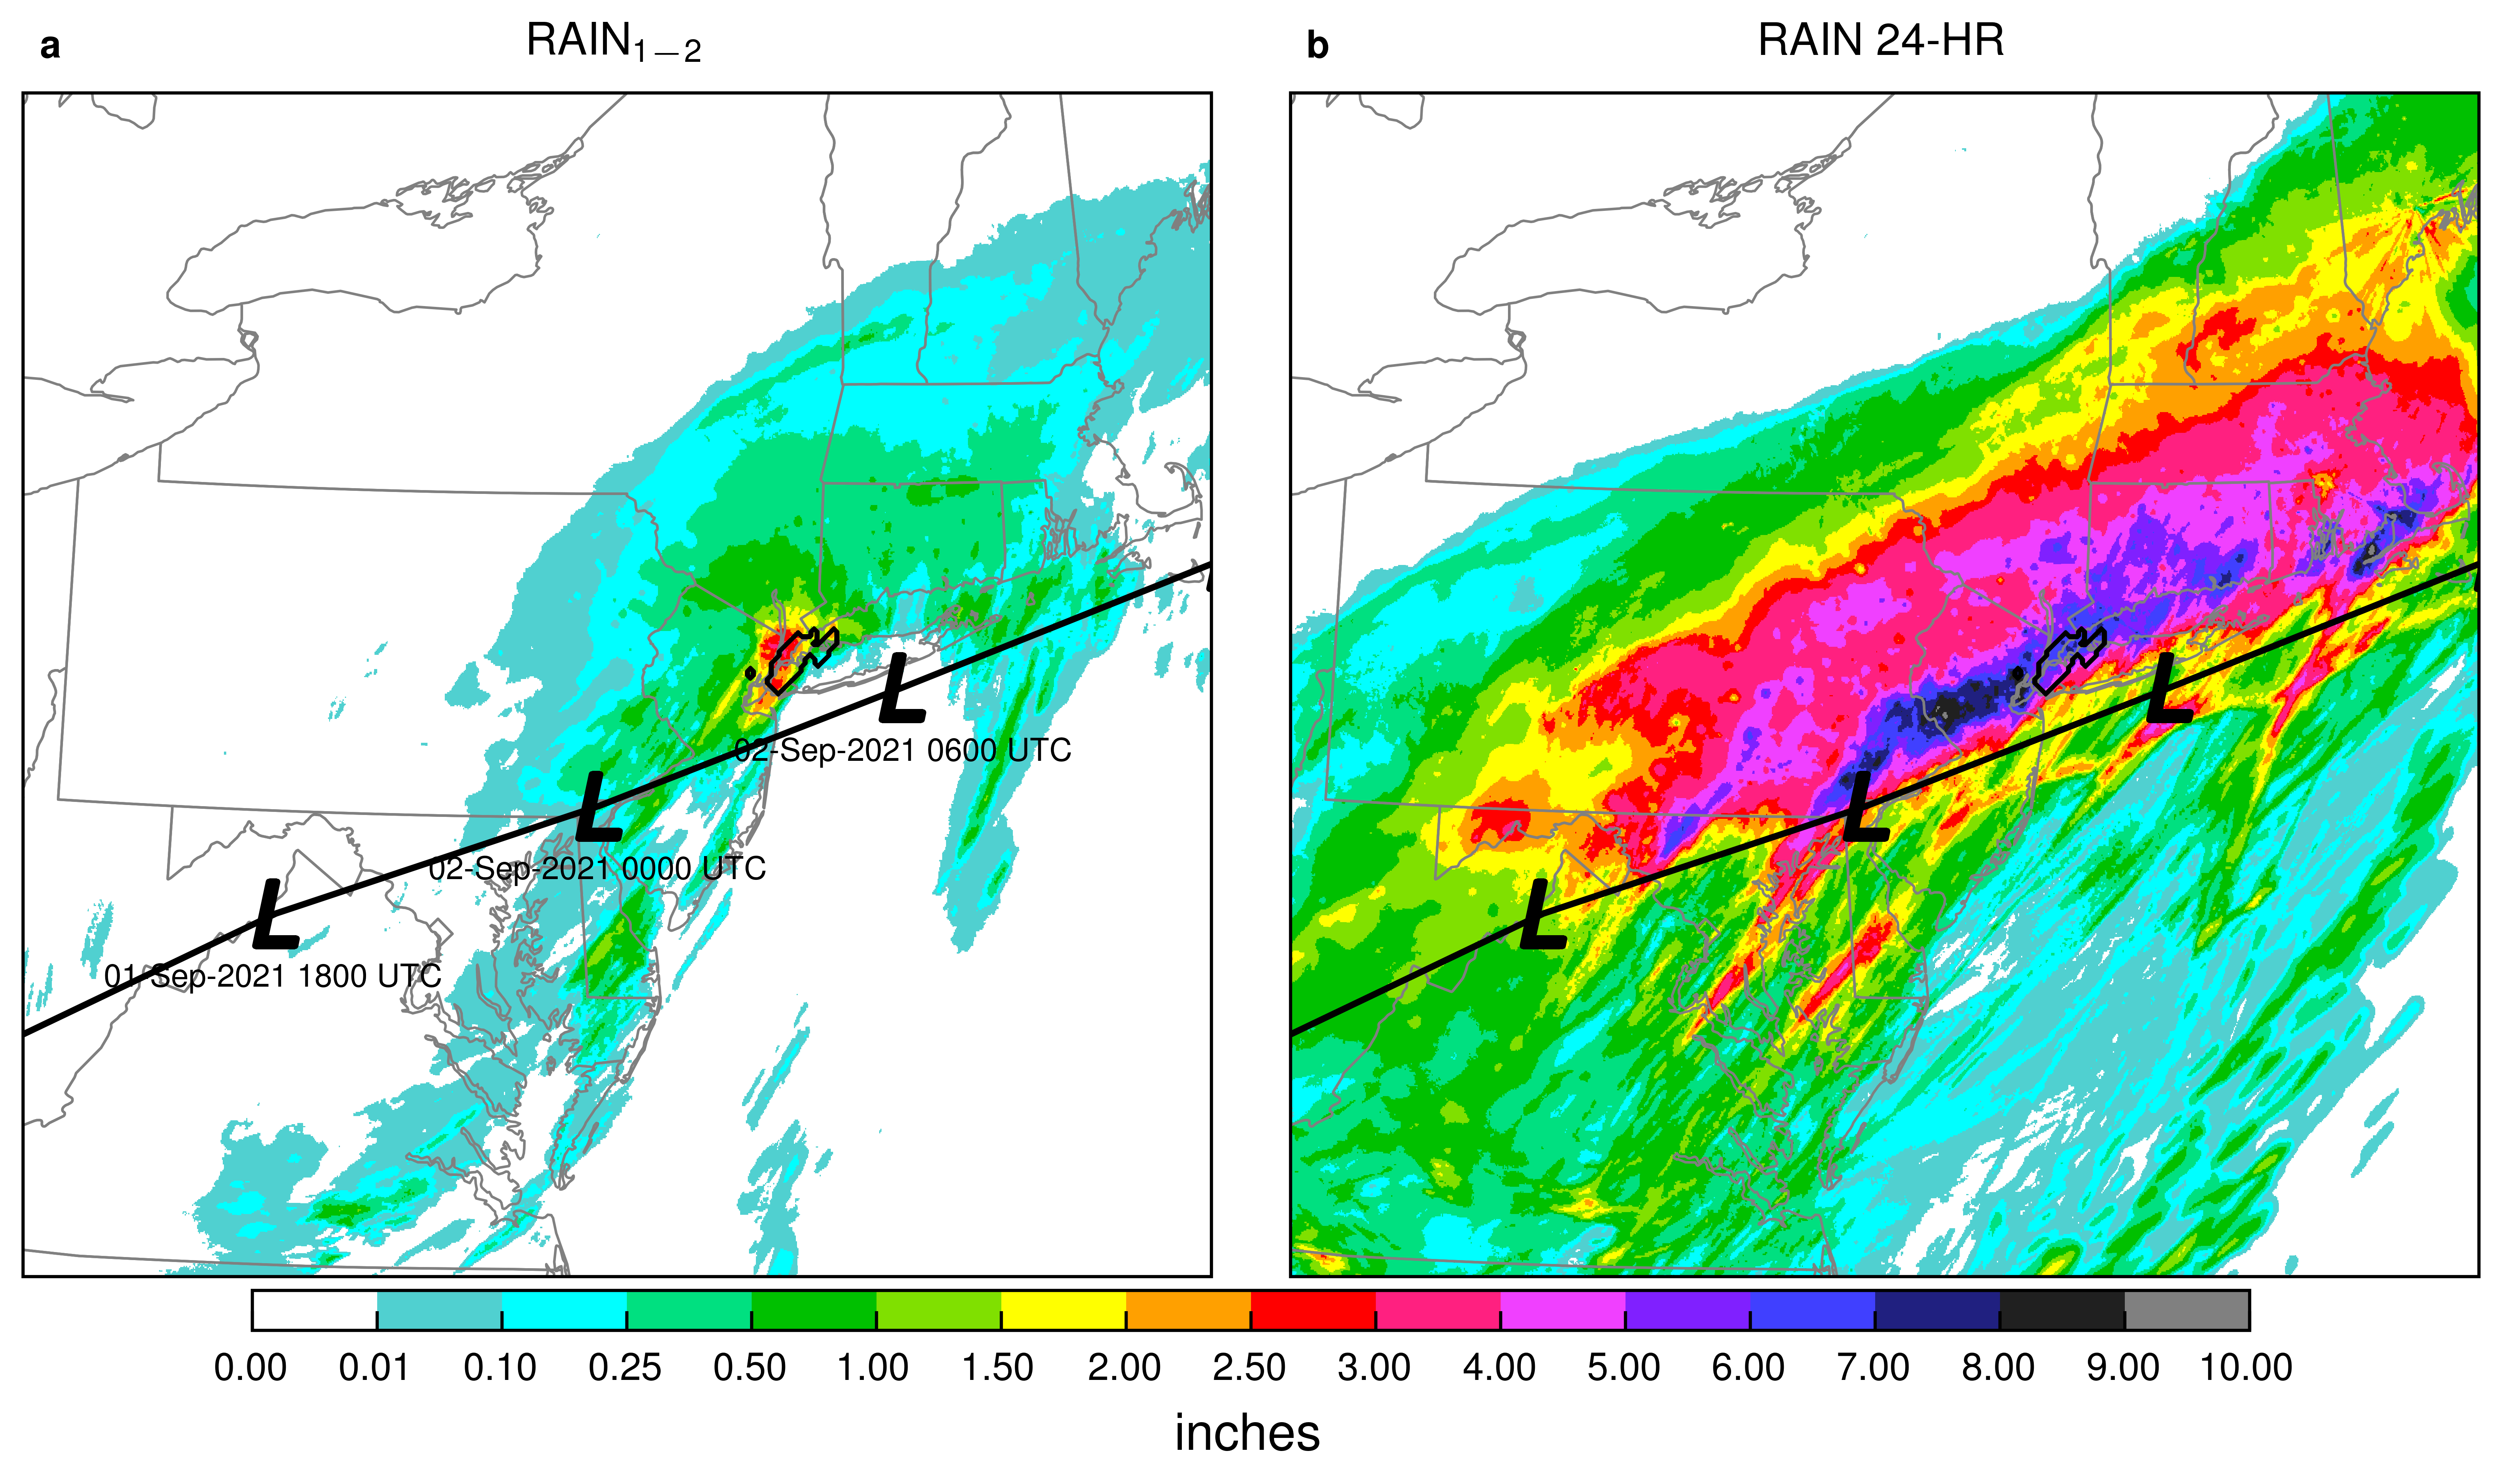

In [ ]:
# Set levels
levels = [0, 0.01, 0.1, 0.25, 0.50, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10]

titles = ["RAIN$_{1-2}$", "RAIN 24-HR"]

letters = ["a", "b"]

# Create a normalization object
norm = mcolors.BoundaryNorm(levels, ncolors=len(levels) - 1, clip=False)

# List of hourly and daily
to_plot = [hourly, daily]

# Make a plot of the hourly rainfall
fig, axes = plt.subplots(
    1,
    2,
    figsize=(5.5, 3.2),
    dpi=600,
    subplot_kw={"projection": proj},
    layout="constrained",
)

for i, ax in enumerate(axes):
    # Define your bounds in degrees
    lat_min, lat_max = 35, 45
    lon_min, lon_max = 278, 292

    cropped = to_plot[i].sel(
        latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max)
    )

    # Also slice lat and lon themselves
    cropped_lat = cropped["latitude"]
    cropped_lon = cropped["longitude"]

    ax.set_extent(  # type: ignore
        [
            -449900.09156094893,
            449900.51654555957,
            -447909.5438942791,
            448284.39736015256,
        ],
        crs=proj,
    )

    pc = ax.pcolormesh(
        cropped_lon,
        cropped_lat,
        cropped / 25.4,
        norm=norm,
        transform=ccrs.PlateCarree(),
        cmap=precip_cmap,  # type: ignore
        rasterized=True,
    )

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray")  # type: ignore

    # Add the AOI
    ax.contour(
        wofs_lon,
        wofs_lat,
        aoi.values,
        levels=[0, 0.5, 1],
        colors=["black"],
        transform=ccrs.PlateCarree(),
        zorder=3,
        linewidths=[0.5],
    )

    ax.text(
        0.015, 1.03, r"\textbf{" + letters[i] + "}", transform=ax.transAxes, fontsize=6
    )

    ax.set_title(titles[i], fontsize=7)

    ax.plot(
        df_ida["Longitude"],
        df_ida["Latitude"],
        color="k",
        marker="$L$",
        markersize=10,
        transform=ccrs.PlateCarree(),
    )

    # Get map extent (xmin, xmax, ymin, ymax)
    x_min, x_max, y_min, y_max = ax.get_extent(crs=ccrs.PlateCarree())

    # Add date & time below the "L" markers (only in the first subplot)
    if i == 0:
        for x, y, date, time in zip(
            df_ida["Longitude"], df_ida["Latitude"], df_ida["Date"], df_ida["Time"]
        ):
            if x_min <= x <= x_max - 1 and y_min <= y <= y_max:
                ax.text(
                    x,
                    y - 0.35,  # Adjust to position below "L"
                    f"{date[6:]}-Sep-{date[:4]} {time[:]} UTC",
                    fontsize=5,
                    color="k",
                    transform=ccrs.PlateCarree(),
                    ha="center",
                    va="top",
                )

# Add colorbar to figure
cb = fig.colorbar(
    pc, ax=axes, orientation="horizontal", pad=0.01, aspect=50, shrink=0.8
)
cb.set_ticks(levels)
cb.set_label("inches", fontsize=8)
cb.ax.tick_params(labelsize=6)

# Save fig as pdf
plt.savefig("figures/Fig1_mrms_rainfall.pdf", bbox_inches="tight")

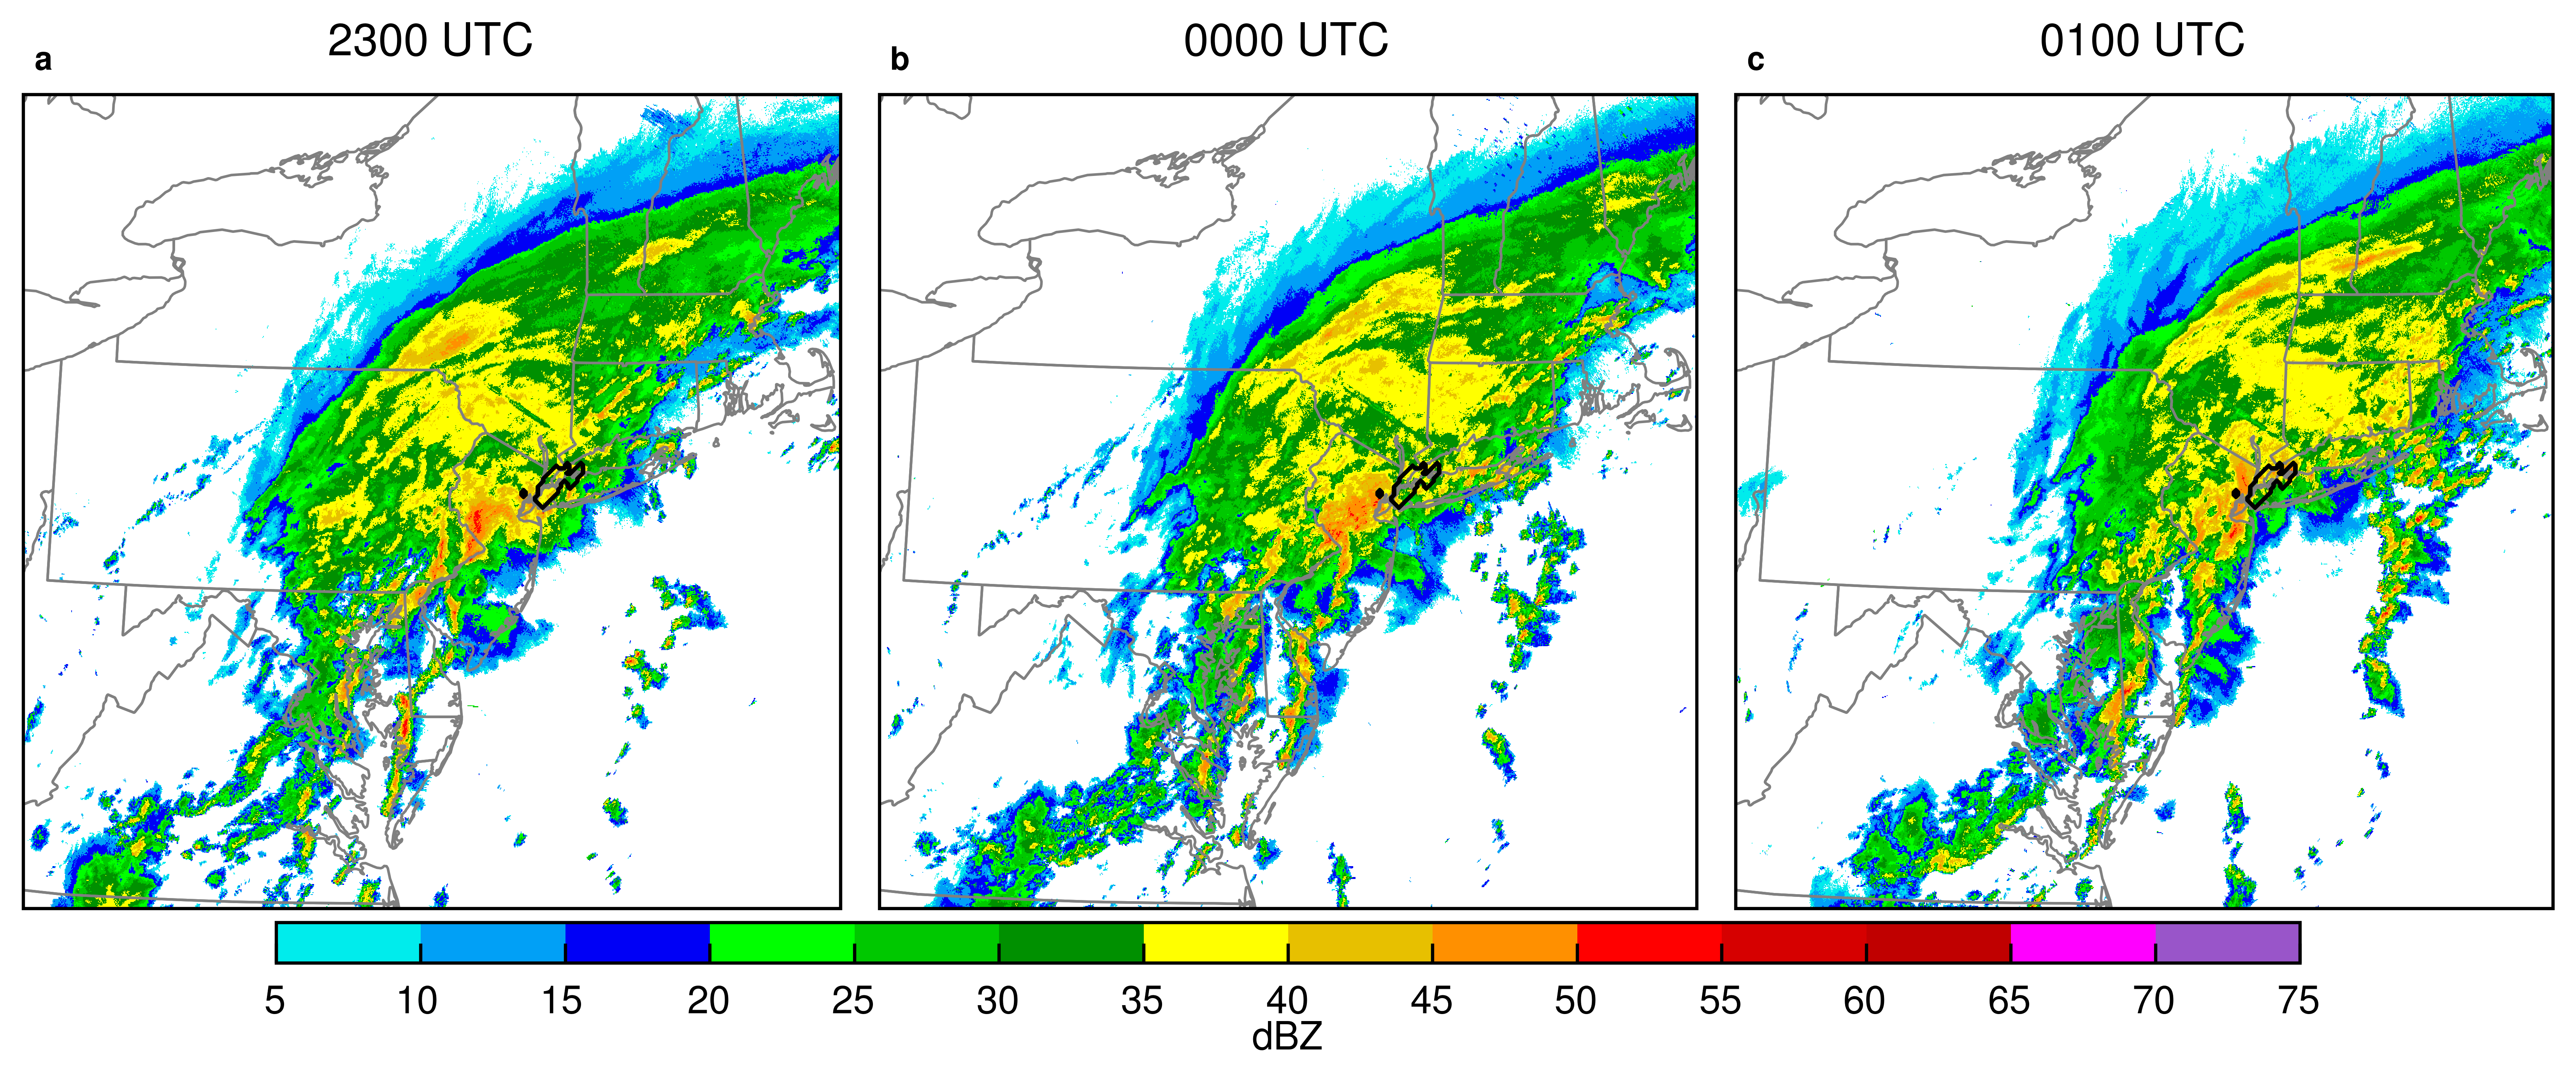

In [ ]:
# Restrict reflectivity to a smaller area and mask values below 5 dBZ
refl_masked = refl.where(
    (abs(refl_lon - 285) < 10) & (abs(refl_lat - 40) < 8), drop=True
).where(refl > 5)

# Set levels
levels = range(5, 76, 5)
letters = ["a", "b", "c"]

titles = ["2300 UTC", "0000 UTC", "0100 UTC"]

# Create a normalization object
norm = mcolors.BoundaryNorm(levels, ncolors=len(levels) - 1, clip=False)

# Make a plot of the hourly rainfall
fig, axes = plt.subplots(
    1,
    3,
    figsize=(5.5, 3),
    dpi=600,
    subplot_kw={"projection": proj},
    layout="constrained",
)

for i, ax in enumerate(axes):
    ax.set_extent(  # type: ignore
        [
            -449900.09156094893,
            449900.51654555957,
            -447909.5438942791,
            448284.39736015256,
        ],
        crs=proj,
    )

    pc = xr.plot.pcolormesh(  # type: ignore
        refl_masked[i, :, :],
        ax=ax,
        norm=norm,
        transform=ccrs.PlateCarree(),
        cmap=refl_cmap,
        extend="neither",
        add_colorbar=False,
        rasterized=True,
    )

    # Add the AOI
    ax.contour(
        wofs_lon,
        wofs_lat,
        aoi.values,
        levels=[0, 0.5, 1],
        colors=["black"],
        transform=ccrs.PlateCarree(),
        zorder=3,
        linewidths=[0.5],
    )

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray")
    ax.set_title(titles[i], fontsize=7)

    ax.text(
        0.015, 1.03, r"\textbf{" + letters[i] + "}", transform=ax.transAxes, fontsize=5
    )

# Add colorbar to figure
cb = fig.colorbar(
    pc, ax=axes, orientation="horizontal", pad=0.01, aspect=50, shrink=0.8
)
cb.set_ticks(levels)
cb.set_label("dBZ", fontsize=6, labelpad=0.01)
cb.ax.tick_params(labelsize=6)

# Save fig as pdf
plt.savefig("figures/Fig5_mrms_refl.pdf", bbox_inches="tight")

### Azimuthal Shear

In [ ]:
# Set up S3 client
s3 = boto3.client(
    "s3", region_name="us-east-1", config=Config(signature_version=UNSIGNED)
)
# List objects from AWS Bucket
response = s3.list_objects_v2(
    Bucket="noaa-mrms-pds", Prefix="CONUS/MergedAzShear_0-2kmAGL_00.50/20210901/"
)

# Get the list of objects
da_list = []
for obj in response["Contents"]:
    if int(obj["Key"][-15:-9]) >= 230000:
        key = obj["Key"]

        # Download the object
        grib_data = BytesIO()
        s3.download_fileobj("noaa-mrms-pds", key, grib_data)
        grib_data.seek(0)

        # Save the object to a temporary file
        with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tmp_file:
            with gzip.open(grib_data, "rb") as f:
                tmp_file.write(f.read())
            tmp_file_path = tmp_file.name

            da = xr.open_dataarray(tmp_file_path, engine="cfgrib")
            da_list.append(da)

# repeat for the next day before 0100 UTC
response = s3.list_objects_v2(
    Bucket="noaa-mrms-pds", Prefix="CONUS/MergedAzShear_0-2kmAGL_00.50/20210902/"
)

# Get the list of objects
for obj in response["Contents"]:
    if int(obj["Key"][-15:-9]) <= 20000:
        key = obj["Key"]

        # Download the object
        grib_data = BytesIO()
        s3.download_fileobj("noaa-mrms-pds", key, grib_data)
        grib_data.seek(0)

        # Save the object to a temporary file
        with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tmp_file:
            with gzip.open(grib_data, "rb") as f:
                tmp_file.write(f.read())
            tmp_file_path = tmp_file.name

            da = xr.open_dataarray(tmp_file_path, engine="cfgrib")
            da_list.append(da)

# Concatenate the DataArrays along the time dimension
shear = xr.concat(da_list, dim="time")

ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(18) ignored
ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(18) ignored
/home/janoski/miniforge3/envs/wof/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-ze

In [11]:
shear_max = (
    shear.where((abs(shear_lon - 285) < 10) & (abs(shear_lat - 40) < 8), drop=True).max(
        dim="time"
    )
    / 1000
)

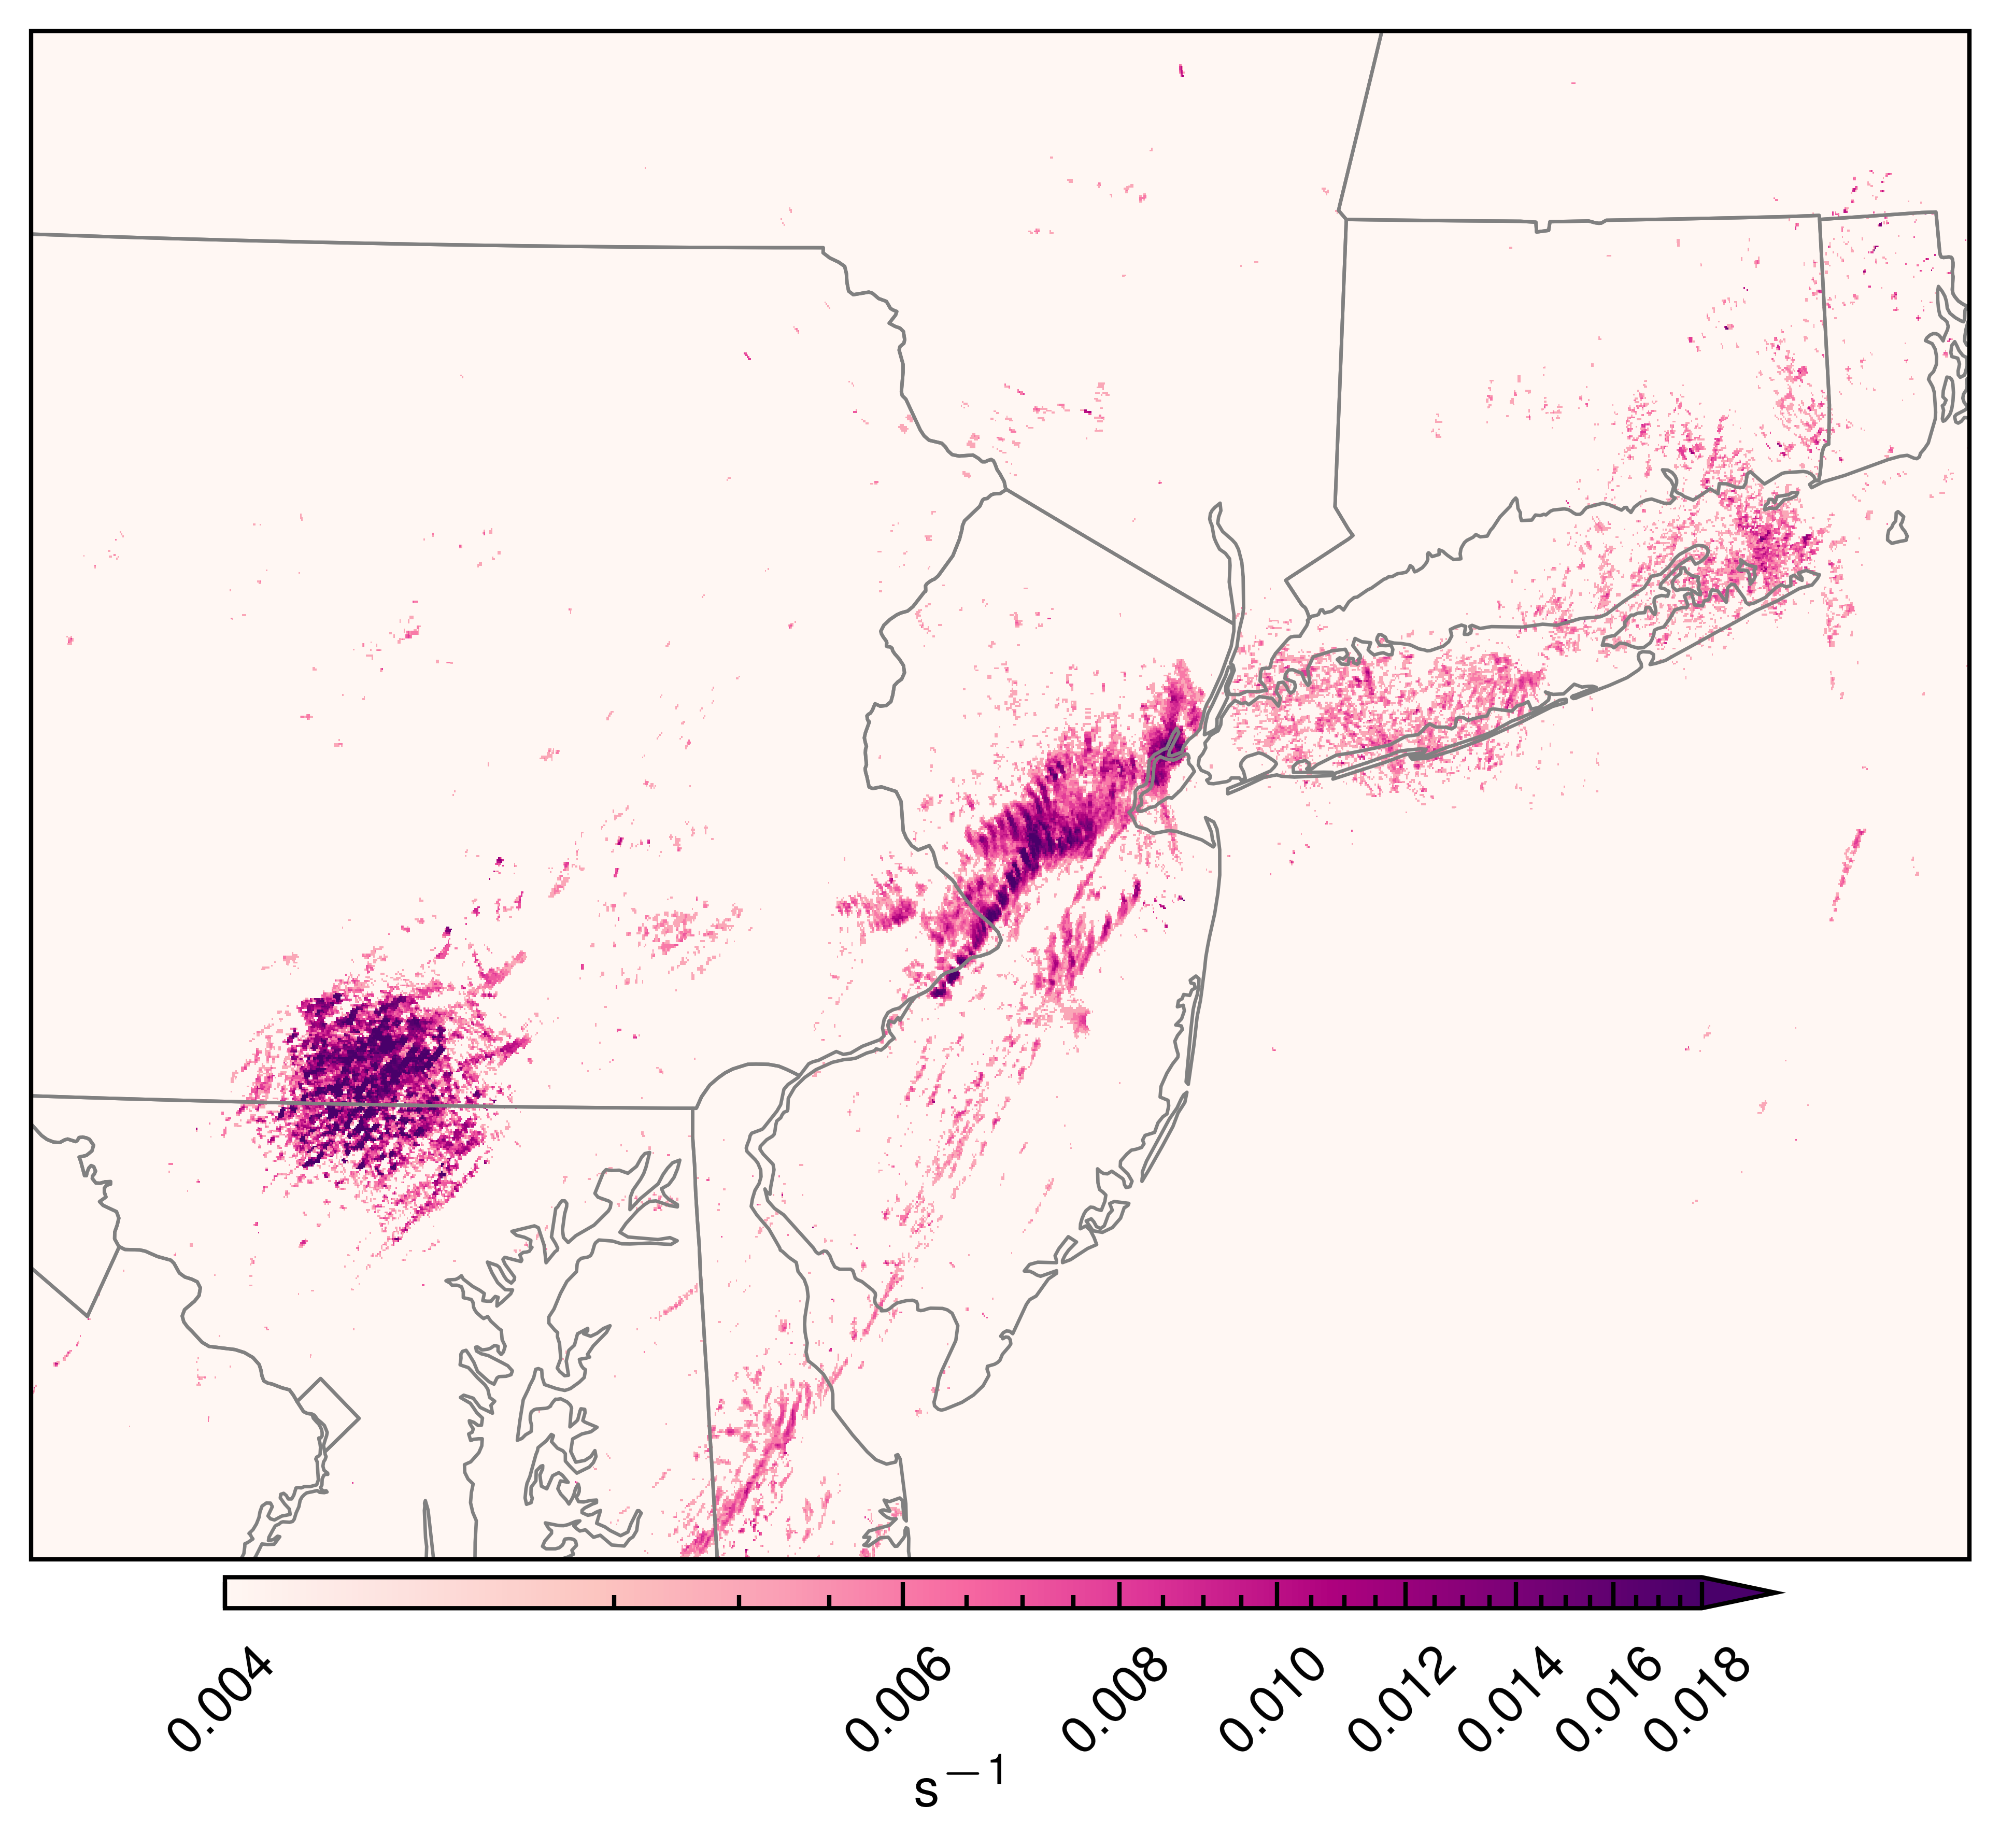

In [ ]:
# Set levels
levels = np.arange(0.004, 0.02, 0.002)

# Make a plot of the hourly rainfall
fig, ax = plt.subplots(
    1,
    1,
    figsize=(3.2, 3),
    dpi=600,
    subplot_kw={"projection": proj},
    layout="constrained",
)

ax.set_extent(
    [-78, -71.5, 38.5, 42.5],  # lon_min, lon_max, lat_min, lat_max
    crs=ccrs.PlateCarree(),
)

pc = xr.plot.pcolormesh(  # type: ignore
    shear_max,
    ax=ax,
    norm=PowerNorm(gamma=0.4, vmin=0.004, vmax=0.018),
    transform=ccrs.PlateCarree(),
    cmap="RdPu",
    extend="max",
    add_colorbar=False,
    vmax=0.018,
    rasterized=True,
)

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray")

ax.set_title("")

# Add colorbar to figure
cb = fig.colorbar(
    pc, ax=ax, orientation="horizontal", pad=0.01, aspect=50, shrink=0.8, extend="max"
)

cb.set_ticks(levels)
cb.set_ticklabels([f"{x:.3f}" for x in levels], rotation=45)
cb.set_label(r"s$^{-1}$", fontsize=6, labelpad=0.01)
cb.ax.tick_params(labelsize=6)

# Save as PDF
plt.savefig("figures/FigS2_mrms_azshr.pdf", bbox_inches="tight")

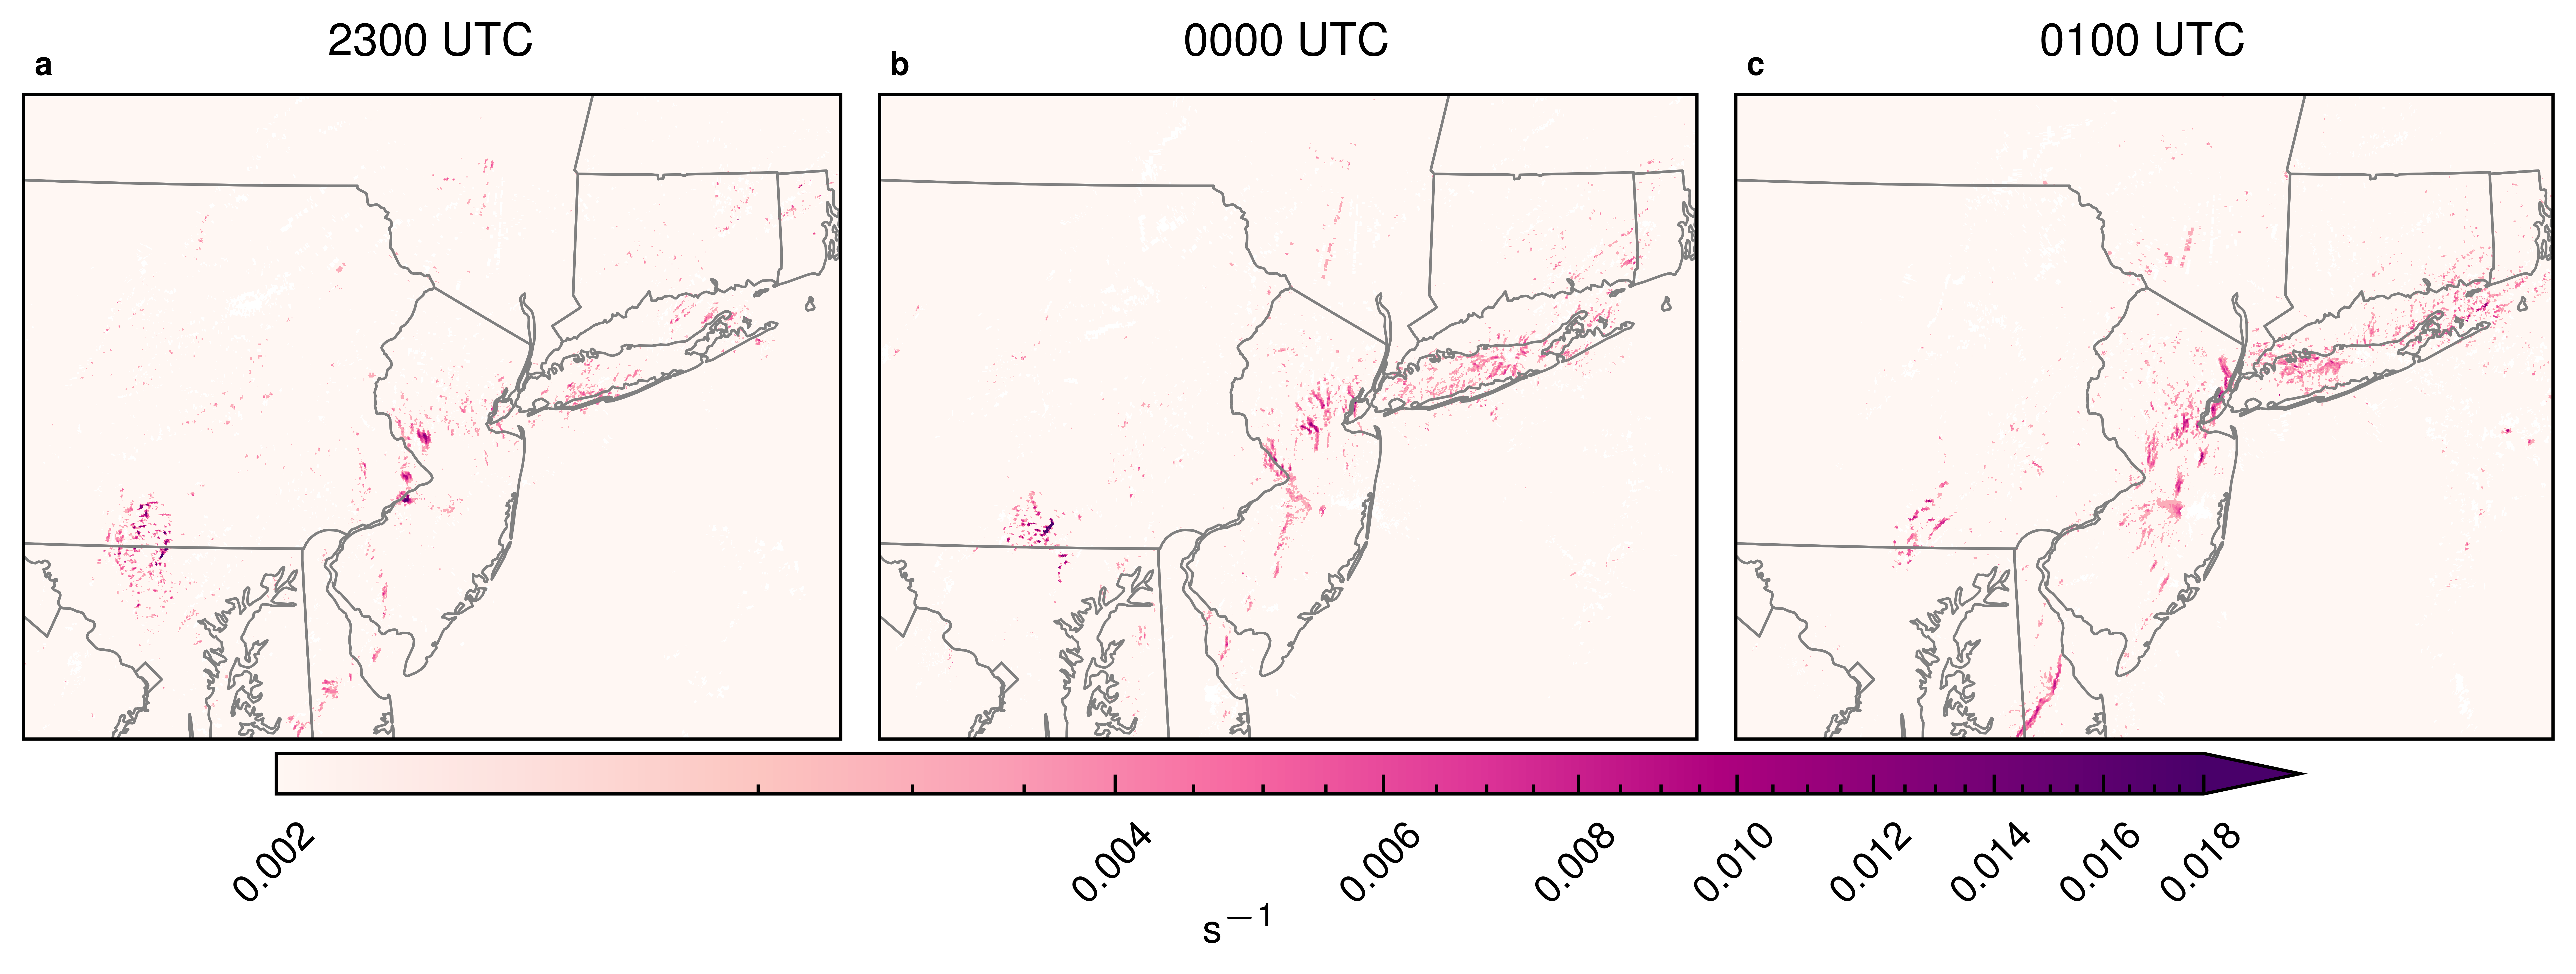

In [ ]:
# Restrict azimuthal shear to a smaller area and mask values below 0 dBZ
shear_masked = (
    shear.where(
        (abs(shear_lon - 285) < 10) & (abs(shear_lat - 40) < 8), drop=True
    ).where(shear >= 0)
    / 1000
)

# Set levels
levels = np.arange(0.002, 0.02, 0.002)
letters = ["a", "b", "c"]

titles = ["2300 UTC", "0000 UTC", "0100 UTC"]

# Make a plot of the hourly rainfall
fig, axes = plt.subplots(
    1,
    3,
    figsize=(5.5, 3),
    dpi=900,
    subplot_kw={"projection": proj},
    layout="constrained",
)

for i, ax in enumerate(axes):
    ax.set_extent(
        [-78, -71.5, 38.5, 42.5],  # lon_min, lon_max, lat_min, lat_max
        crs=ccrs.PlateCarree(),
    )

    pc = xr.plot.pcolormesh(  # type: ignore
        shear_masked[i, :, :],
        ax=ax,
        norm=PowerNorm(gamma=0.4, vmin=0.002, vmax=0.018),
        transform=ccrs.PlateCarree(),
        cmap="RdPu",
        extend="max",
        add_colorbar=False,
        vmax=0.018,
    )

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="gray")
    ax.set_title(titles[i], fontsize=7)

    ax.text(
        0.015, 1.03, r"\textbf{" + letters[i] + "}", transform=ax.transAxes, fontsize=5
    )

# Add colorbar to figure
cb = fig.colorbar(
    pc, ax=axes, orientation="horizontal", pad=0.01, aspect=50, shrink=0.8, extend="max"
)
cb.set_ticks(levels)
cb.set_ticklabels([f"{x:.3f}" for x in levels], rotation=45)
cb.set_label(r"s$^{-1}$", fontsize=6, labelpad=0.01)
cb.ax.tick_params(labelsize=6)

plt.show()


In [64]:
# Calculate the hourly maximum shear
hourly_max_shear = (
    shear.isel(time=slice(None, -1))
    .sel(longitude=slice(280, 290), latitude=slice(45, 35))
    .groupby("time.hour")
    .max(dim="time")
    .sel(hour=[23, 0, 1])
    / 1000
)

In [49]:
# Restrict reflectivity to a smaller area and mask values below 5 dBZ
refl_masked = refl.sel(longitude=slice(280, 290), latitude=slice(45, 35)).where(
    refl > 5
)


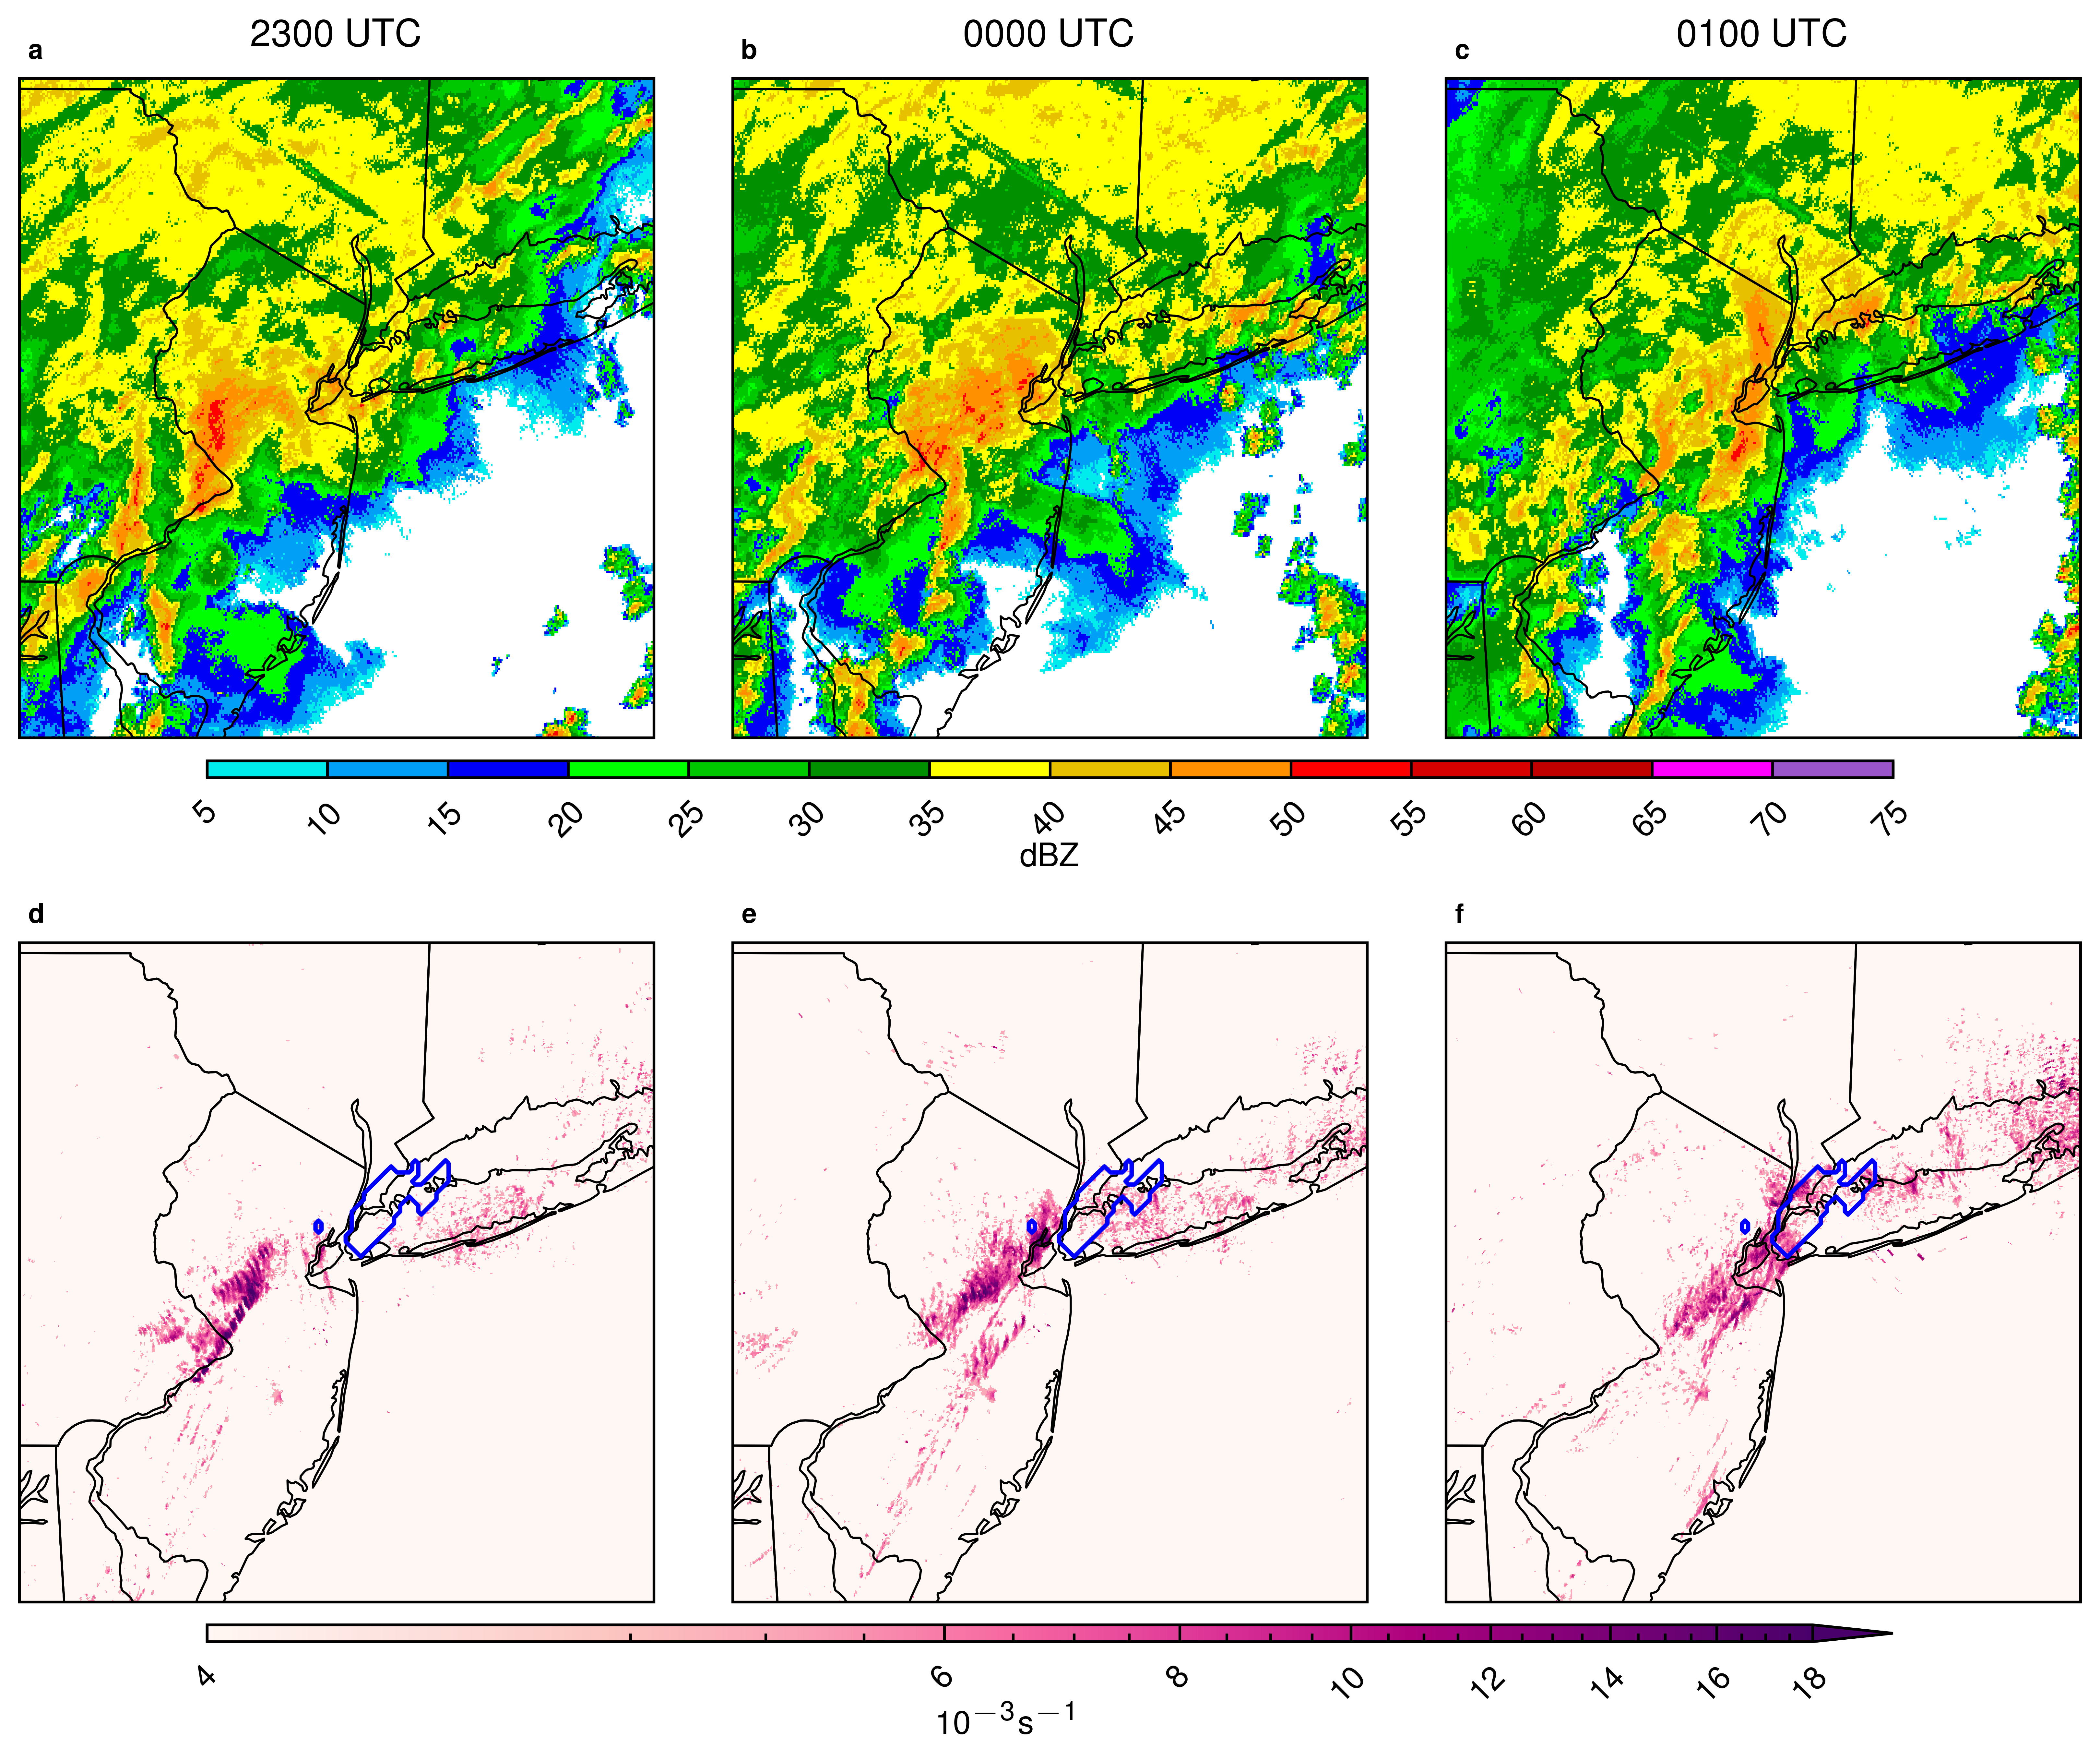

In [85]:
# Make a plot of the hourly rainfall
fig, axes = plt.subplots(
    2,
    3,
    figsize=(5.5, 4.5),
    dpi=600,
    subplot_kw={"projection": proj},
    layout="constrained",
)

# Set levels
refl_levs = range(5, 76, 5)
azshear_levs = np.arange(4, 20, 2)

# Set letters
letters = ["a", "b", "c", "d", "e", "f"]

# Set titles
titles = ["2300 UTC", "0000 UTC", "0100 UTC"]

# Create a normalization object for refl levels
refl_norm = mcolors.BoundaryNorm(refl_levs, ncolors=len(refl_levs) - 1, clip=False)
azshear_norm = PowerNorm(gamma=0.4, vmin=4, vmax=18)

# Set data to plot
data_to_plot = [refl_masked.isel(time=i) for i in range(3)] + [
    hourly_max_shear.isel(hour=i)*1000 for i in range(3)
]

# Plot
for i, ax in enumerate(axes.flat):
    # Restrict extent
    ax.set_extent(
        [-76, -72.25, 39, 42],  # lon_min, lon_max, lat_min, lat_max
        crs=ccrs.PlateCarree(),
    )

    # pcolormesh
    pc = xr.plot.pcolormesh(  # type: ignore
        data_to_plot[i],
        ax=ax,
        norm=refl_norm if i < 3 else azshear_norm,
        transform=ccrs.PlateCarree(),
        cmap=refl_cmap if i < 3 else "RdPu",
        extend="neither",
        add_colorbar=False,
        rasterized=True,
    )

    if(i>=3):
        # Add the AOI
        ax.contour(
            wofs_lon,
            wofs_lat,
            aoi.values,
            levels=[0.5],
            colors=["blue"],
            transform=ccrs.PlateCarree(),
            zorder=3,
            linewidths=[0.8],
        )

    # Plot coastlines
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="black")

    # Set title
    ax.set_title(titles[i] if i < 3 else None, fontsize=7)

    # Add letter
    ax.text(
        0.015, 1.03, r"\textbf{" + letters[i] + "}", transform=ax.transAxes, fontsize=5
    )

    # Create colorbar for each row
    if i % 3 == 0:
        cb = fig.colorbar(
            pc,
            ax=axes[i // 3, :],
            orientation="horizontal",
            pad=0.03,
            aspect=100,
            shrink=0.8,
            extend="max" if i >= 3 else "neither",
        )
        cb.set_ticks(refl_levs if i < 3 else azshear_levs)  # type: ignore
        cb.set_ticklabels(
            refl_levs if i < 3 else azshear_levs,
            rotation=45,
        )
        cb.set_label("dBZ" if i < 3 else r"10$^{-3}$s$^{-1}$", fontsize=6, labelpad=0.01)
        cb.ax.tick_params(labelsize=6)

plt.savefig("figures/Fig5_mrms_refl_azshear.pdf", bbox_inches="tight")